Rendering black hole...


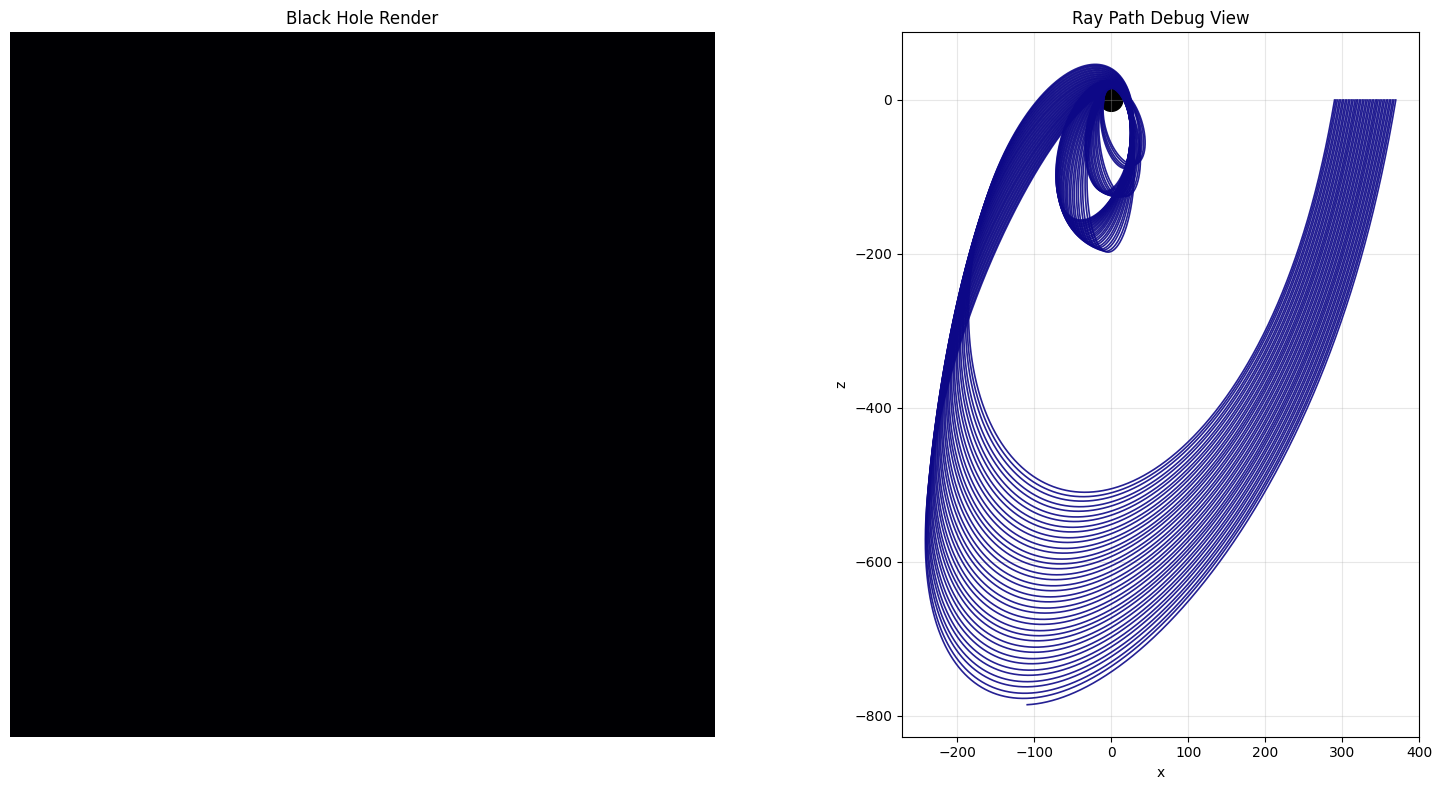

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import constants
from scipy.ndimage import gaussian_filter
import gc

# 175x175 pixels til visualisering og udregninger.
width = 175
height = 175

# Simpelt sort hul. Pixels bliver mørke når de er tæt på midten.
Event_horizon = 15.0

# Position af sort hul og "kamera"
kamera_pos = np.array([0.0, 200.0, 0.0])
black_hole_pos = np.array([0.0, 0.0, 0.0])

# Gem baggrund så den kun skal laves en gang
star_directions = None
image_plane_distance = 100.0
scale = 300.0
bh_mass = 120.0
dt = 0.22
max_steps = 35000

def generate_star_directions():
    global star_directions
    if star_directions is not None:
        return
    num_stars = 320
    star_theta = np.random.uniform(0, 2*np.pi, num_stars)
    star_phi = np.random.uniform(0, np.pi, num_stars)
    star_directions = np.array([
        np.sin(star_phi) * np.cos(star_theta),
        np.sin(star_phi) * np.sin(star_theta),
        np.cos(star_phi)
    ]).T


def trace_ray(x, y, record_path=False, emitter='top_parallel'):
    generate_star_directions()

    path = []

    def intensity():
        intensity = float(np.clip(intensity, 0.0, 1.0))

        if record_path:
            return intensity, np.array(path)

        return intensity

    px = (x / width * 2 - 1) * scale
    py = (y / height * 2 - 1) * scale

    # Determine emitter position and ray direction
    if emitter == 'camera':
        emitter_pos = kamera_pos
        image_point = emitter_pos + np.array([px, py, image_plane_distance])
        ray_dir = image_point - emitter_pos
        ray_dir = ray_dir / np.linalg.norm(ray_dir)
    elif emitter == 'top':
        emitter_pos = np.array([0.0, 500.0, 0.0])
        image_point = emitter_pos + np.array([px, -image_plane_distance, py])
        ray_dir = image_point - emitter_pos
        ray_dir = ray_dir / np.linalg.norm(ray_dir)
    elif emitter == 'right_parallel':
        # Parallel rays from the right, all traveling in -x direction
        py_start = (y / height * 2 - 1) * scale
        pz_start = (x / width * 2 - 1) * scale
        ray_pos = np.array([700.0, py_start, pz_start + 615.0])
        ray_dir = np.array([-1.0, 0.0, 0.0])
    elif emitter == 'top_parallel':

        spread = 40.0

        px_start = (x / width * 2 - 1) * spread
        pz_start = (y / height * 2 - 1) * spread

        ray_pos = np.array([
        px_start+ 330.0,
        350.0,
        pz_start
        ])

        ray_dir = np.array([0.0, -1.0, 0.0])

        velocity = ray_dir.copy()

        # direction toward black hole (important!)
        to_bh = black_hole_pos - ray_pos
        to_bh /= (np.linalg.norm(to_bh) + 1e-8)

        # build perpendicular direction (orbital direction)
        tangent = np.array([-to_bh[2], 0.0, to_bh[0]])

        # initial velocity is mostly tangential, not downward
        velocity = tangent * 1.2 + to_bh * 0.2

    else:
        emitter_pos = kamera_pos
        image_point = emitter_pos + np.array([px, py, image_plane_distance])
        ray_dir = image_point - emitter_pos
        ray_dir = ray_dir / np.linalg.norm(ray_dir)

    if emitter not in ('right_parallel', 'top_parallel'):
        ray_pos = emitter_pos.copy()
    
    path = []

    if record_path:
        path.append(ray_pos.copy())
    min_distance = np.inf

    previous_angle = None
    total_angle = 0.0

    for _ in range(max_steps):
        diff = black_hole_pos - ray_pos
        distance = np.linalg.norm(diff)
        
        angle = np.arctan2(ray_pos[2], ray_pos[0])

        if previous_angle is not None:
            dtheta = angle - previous_angle

            if dtheta > np.pi:
                dtheta -= 2*np.pi
            elif dtheta < -np.pi:
                dtheta += 2*np.pi
            total_angle += abs(dtheta)

        previous_angle = angle

        min_distance = min(min_distance, distance)
        if distance < Event_horizon:
            intensity = 0.0
            if record_path:
                return intensity, np.array(path)
        
            return intensity

        if distance > 0.001:
            direction_to_bh = diff / (distance + 1e-8)

            # softened gravity
            gravity_strength = bh_mass / (distance**2 + 120.0)

            # pure central force (NO fake tangent force)
            acceleration = direction_to_bh * gravity_strength

            # integrate velocity
            velocity += acceleration * dt

            # optional light damping (you can remove if you want cleaner physics)
            velocity *= 0.9999

            # update position
            ray_pos += velocity * dt
                
        if distance > 800 and np.dot(ray_dir, diff) < 0:
            break
        if record_path:
            path.append(ray_pos.copy())

    
    photon_ring_radius = Event_horizon * 1.5
    ring_width = Event_horizon * 0.22

    glow = np.exp(
        -((min_distance - photon_ring_radius) ** 2)
        / (2 * ring_width**2)
    )

    orbit_boost = min(total_angle / (2*np.pi), 3.0)

    intensity = glow * (1.0 + orbit_boost * 3.0)

    intensity = np.clip(intensity, 0.0, 1.0)

    if record_path:
        return intensity, np.array(path)

    return intensity


def render(num_samples=500, emitter='camera'):
    image = np.zeros((height, width), dtype=float)
    center_y, center_x = height // 2, width // 2
    max_trace_radius = Event_horizon * 3.0

#loader kun nogen pixels så den loader meget hurtigere
    y_coords, x_coords = np.where(
        np.hypot(np.arange(height)[:, None] - center_y,
                 np.arange(width)[None, :] - center_x) <= max_trace_radius,
    )
    num_samples = min(num_samples, len(x_coords))
    sample_indices = np.random.choice(len(x_coords), size=num_samples, replace=False)

    for idx in sample_indices:
        y = y_coords[idx]
        x = x_coords[idx]

        intensity, path = trace_ray(
            x,
            y,
            emitter=emitter,
            record_path=True
        )

        # draw full trajectory into image
        for p in path:

            view_scale = 120.0

            ix = int((p[0] / view_scale) + width / 2)
            iz = int((p[2] / view_scale) + height / 2)

            if 0 <= ix < width and 0 <= iz < height:
                image[iz, ix] += 0.02 * intensity
    return image


def sample_ray_paths(emitter='top_parallel'):
    sample_x = np.linspace(0, width - 1, 40, dtype=int)
    sample_y = np.full_like(sample_x, height // 2)
    paths = []
    for x, y in zip(sample_x, sample_y):
        intensity, path = trace_ray(x, y, record_path=True, emitter=emitter)
        paths.append((path, intensity))
    return paths

# da black hole
# Vi vil sætte det sorte hul ved koordinaterne (0,0,0) og kameraet ved (0,0,-500) så vi kigger på det sorte hul

if __name__ == "__main__":

    print("Rendering black hole...")

    emitter_choice = 'top_parallel'

    image = render(
        num_samples=500,
        emitter=emitter_choice
    )

    # Optional cinematic blur
    from scipy.ndimage import gaussian_filter
    image = gaussian_filter(image, sigma=1.0)

    # Soft brightness scaling instead of hard normalization
    image = gaussian_filter(image, sigma=1.2)

    image /= (np.max(image) + 1e-8)

    image = image ** 0.6

    
    ray_paths = sample_ray_paths(emitter=emitter_choice)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 8)
    )

    axes[0].imshow(
        image,
        cmap='magma',
        origin='lower',
        vmin=0,
        vmax=1
    )

    axes[0].set_title("Black Hole Render")
    axes[0].axis('off')


    for path, intensity in ray_paths:

        color = plt.cm.plasma(float(np.clip(intensity, 0.0, 1.0)))

        axes[1].plot(
            path[:, 0],
            path[:, 2],
            color=color,
            linewidth=1.2,
            alpha=0.9
        )


axes[1].set_title("Ray Path Debug View")

axes[1].set_xlabel("x")
axes[1].set_ylabel("z")

axes[1].set_aspect('equal')

axes[1].grid(alpha=0.3)

# Draw black hole
horizon = plt.Circle(
    (0, 0),
    Event_horizon,
    color='black'
)

axes[1].add_patch(horizon)

plt.tight_layout()
plt.show()